In [2]:
# LIBRERIAS A USAR
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CARPETA = r"C:\Users\jhonn\Desktop\NEOLAND\PROYECTO\PROYECTO_BOOTCAMP_ALQUILER\03_dataset_final"

# Cargar el dataset del modelo (100 barrios con precio)
df = pd.read_csv(os.path.join(CARPETA, "dataset_barrios_modelo.csv"),
                 dtype={"id_barrio": str, "cod_distrito": str})

# ¿Cuántas filas y columnas?
print("Filas y columnas:", df.shape)

# ¿Qué tipo de dato tiene cada columna?
print()
print(df.dtypes)

# Ver las primeras filas
df.head(50)



Filas y columnas: (100, 11)

id_barrio                object
cod_distrito             object
nombre_distrito          object
nombre_barrio            object
lat_c                   float64
lon_c                   float64
precio_m2               float64
densidad_airbnb         float64
renta_media_persona     float64
distancia_centro_km     float64
crec_demografico_pct    float64
dtype: object


,id_barrio,cod_distrito,nombre_distrito,nombre_barrio,lat_c,lon_c,precio_m2,densidad_airbnb,renta_media_persona,distancia_centro_km,crec_demografico_pct
0,01011,01,Centro,Palacio,40.414963,-3.715599,24.6,7.7696,23.770,1.048,3.474589
1,01012,01,Centro,Embajadores,40.409556,-3.701533,25.7,5.6771,18.177,0.838,5.034074
2,01013,01,Centro,Cortes,40.414428,-3.698533,26.1,9.9760,24.671,0.508,3.229181
3,01014,01,Centro,Justicia,40.423892,-3.695810,27.9,6.0332,28.051,1.011,2.814005
4,01015,01,Centro,Universidad,40.425368,-3.706673,25.9,5.6240,22.689,0.972,3.859040
5,01016,01,Centro,Sol,40.416914,-3.704449,25.5,16.4328,21.020,0.078,4.103179
6,02021,02,Arganzuela,Imperial,40.406933,-3.717434,21.9,0.9165,23.591,1.621,1.256298
7,02022,02,Arganzuela,Acacias,40.400963,-3.706857,21.8,0.5454,24.444,1.797,1.119321
8,02023,02,Arganzuela,Chopera,40.394799,-3.699528,22.4,0.7400,18.830,2.482,2.473949
9,02024,02,Arganzuela,Legazpi,40.388086,-3.688609,19.6,0.3021,25.356,3.445,1.983421


In [3]:
# ¿Faltan datos en alguna columna?
print("Nulos por columna:")
print(df.isnull().sum())

# ¿Hay algún barrio repetido?
print()
print("Barrios repetidos:", df["id_barrio"].duplicated().sum())

# ¿Hay valores imposibles?
print()
print("Precios fuera de 5-60 €/m²:", (~df["precio_m2"].between(5, 60)).sum())
print("Densidad Airbnb negativa:", (df["densidad_airbnb"] < 0).sum())
print("Renta fuera de 5-100 mil €:", (~df["renta_media_persona"].between(5, 100)).sum())
print("Distancia negativa:", (df["distancia_centro_km"] < 0).sum())

# ¿Cuántos barrios hay de cada distrito?
print()
print("Barrios por distrito:")
print(df["nombre_distrito"].value_counts())

Nulos por columna:
id_barrio               0
cod_distrito            0
nombre_distrito         0
nombre_barrio           0
lat_c                   0
lon_c                   0
precio_m2               0
densidad_airbnb         0
renta_media_persona     0
distancia_centro_km     0
crec_demografico_pct    0
dtype: int64

Barrios repetidos: 0

Precios fuera de 5-60 €/m²: 0
Densidad Airbnb negativa: 0
Renta fuera de 5-100 mil €: 0
Distancia negativa: 0

Barrios por distrito:
nombre_distrito
Ciudad Lineal            8
Arganzuela               6
Retiro                   6
Salamanca                6
Centro                   6
Chamartín                6
Tetuán                   6
Fuencarral - El Pardo    6
Chamberí                 6
Carabanchel              6
Moncloa - Aravaca        6
Hortaleza                5
Latina                   5
San Blas - Canillejas    5
Puente de Vallecas       4
Usera                    3
Villaverde               3
Vicálvaro                2
Villa de Vallecas       

       precio_m2  densidad_airbnb  renta_media_persona  distancia_centro_km  \
count     100.00           100.00               100.00               100.00   
mean       21.19             0.99                22.02                 5.13   
std         3.57             2.19                 7.10                 2.97   
min        15.10             0.02                 9.91                 0.08   
25%        18.88             0.19                15.34                 2.87   
50%        20.45             0.42                22.51                 4.75   
75%        23.45             0.89                27.26                 6.98   
max        31.60            16.43                36.92                13.72   

       crec_demografico_pct  
count                100.00  
mean                   3.45  
std                    2.83  
min                    0.28  
25%                    2.22  
50%                    3.02  
75%                    4.39  
max                   27.37  

precio_m2: media 

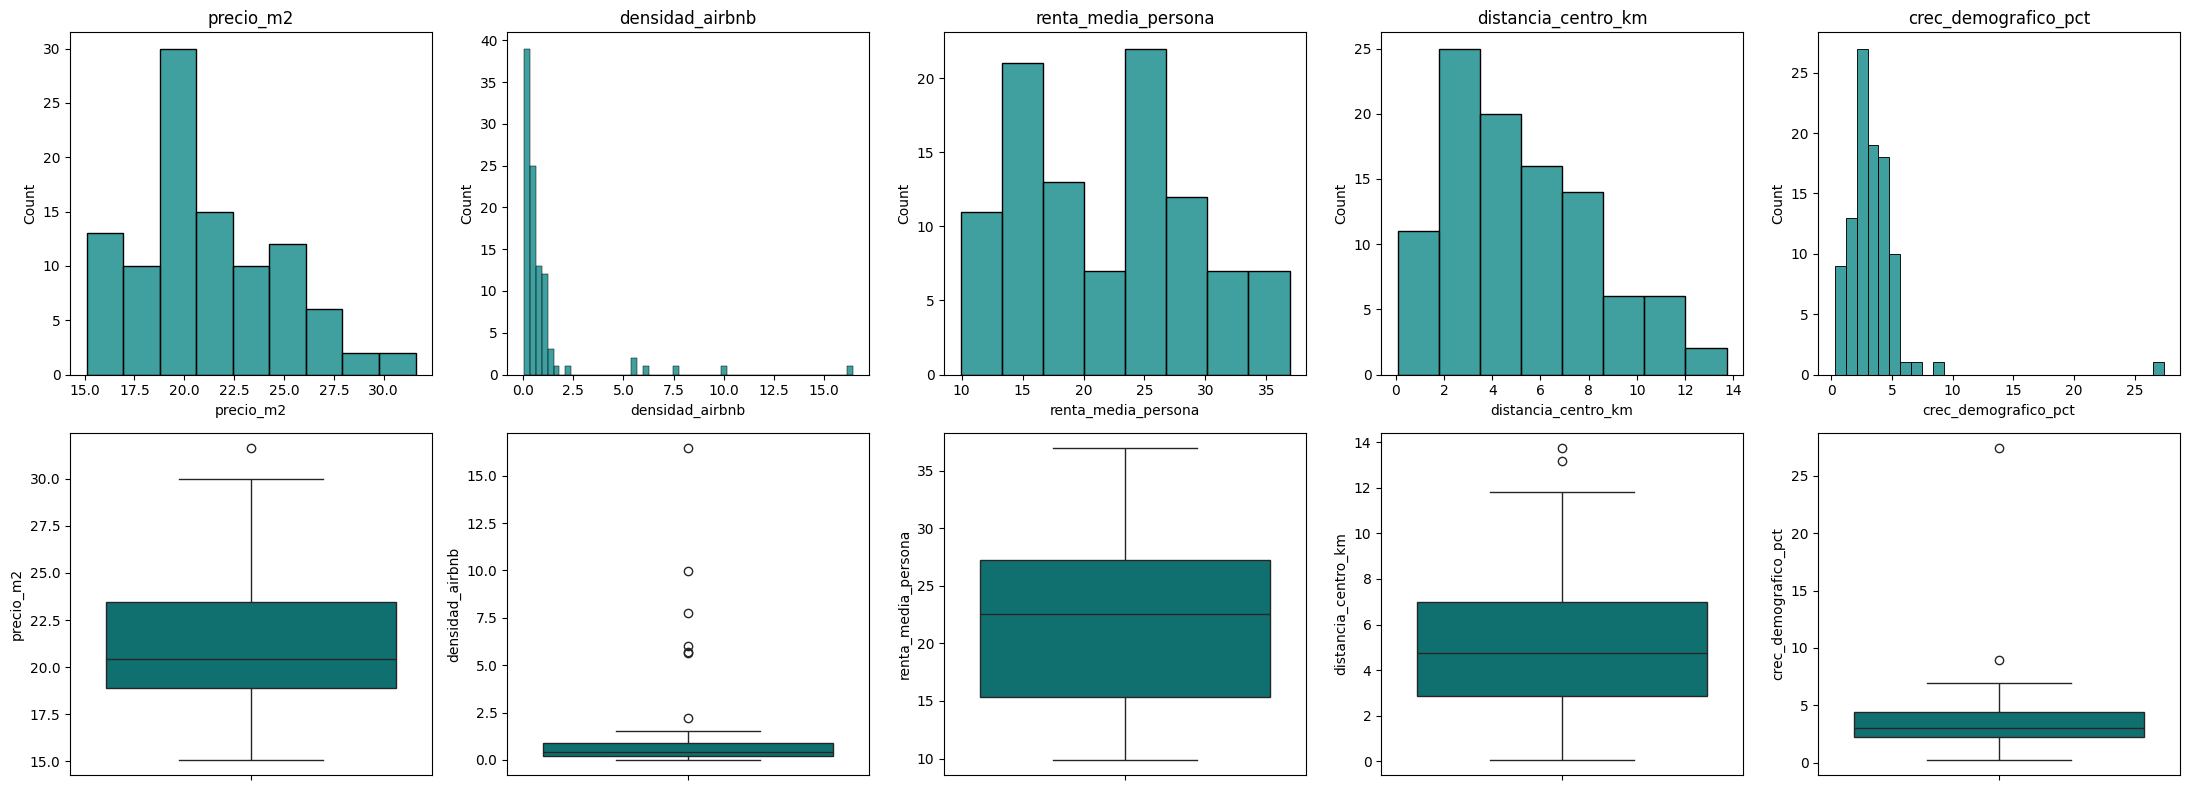

In [4]:
variables = ["precio_m2", "densidad_airbnb", "renta_media_persona",
             "distancia_centro_km", "crec_demografico_pct"]

# Tabla de resumen
print(df[variables].describe().round(2))

# Media frente a mediana: si están lejos, hay unos pocos barrios extremos
print()
for var in variables:
    print(f"{var}: media {df[var].mean():.2f} | mediana {df[var].median():.2f}")

# Histograma (arriba) y boxplot (abajo) de cada variable
fig, ax = plt.subplots(2, 5, figsize=(22, 8))
for i, var in enumerate(variables):
    sns.histplot(df[var], ax=ax[0, i], color="teal")
    ax[0, i].set_title(var)
    sns.boxplot(y=df[var], ax=ax[1, i], color="teal")
plt.tight_layout()
plt.show()

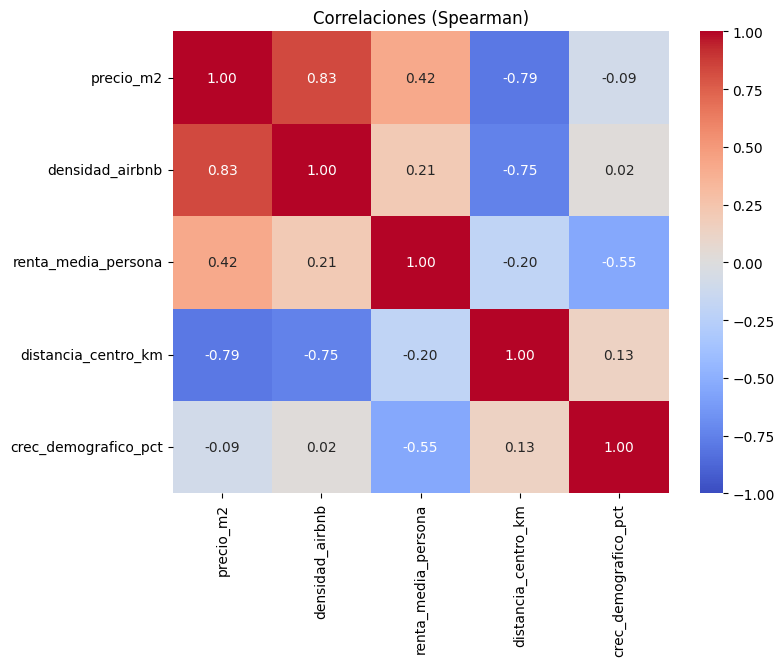

Correlación con el precio (Spearman):
densidad_airbnb         0.83
distancia_centro_km    -0.79
renta_media_persona     0.42
crec_demografico_pct   -0.09
Name: precio_m2, dtype: float64


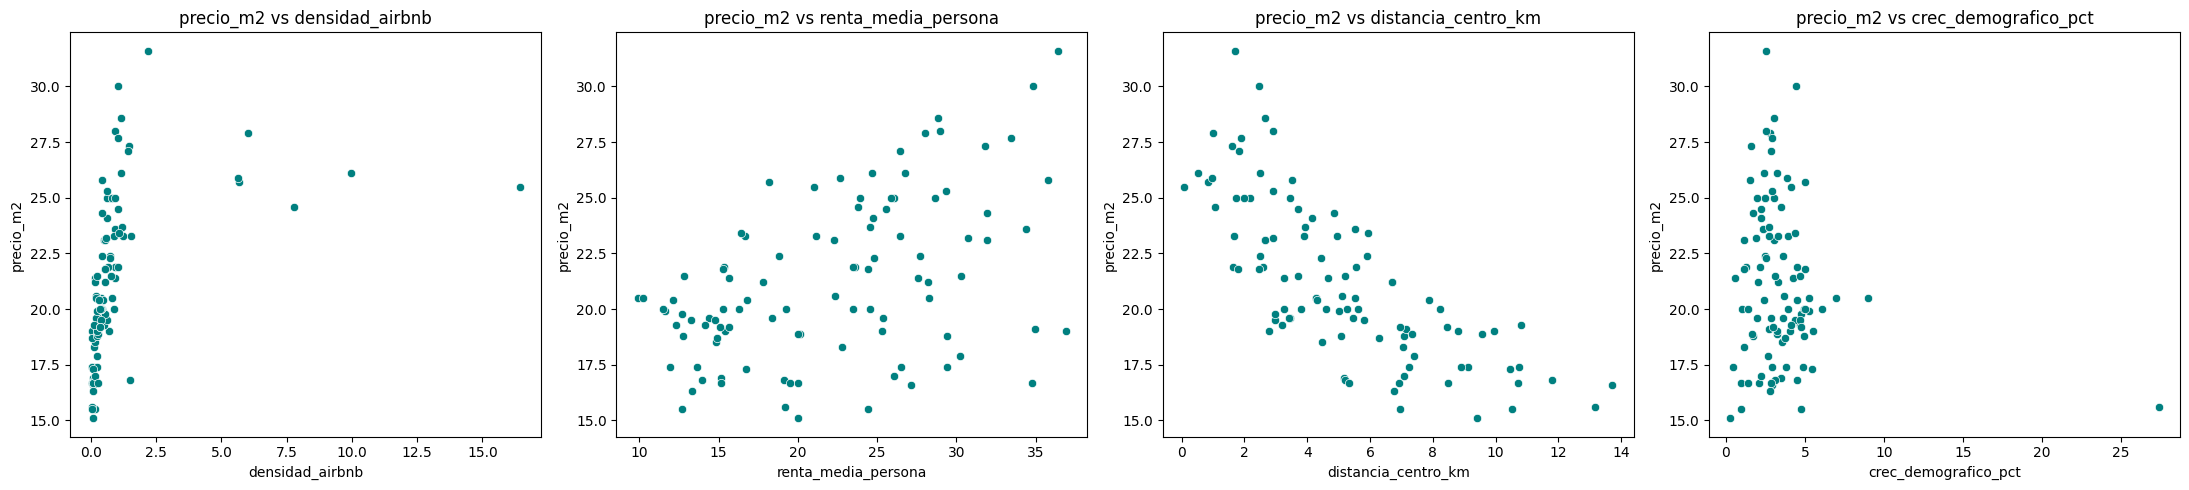

In [5]:
# --- Heatmap de correlaciones ---
plt.figure(figsize=(8, 6))
sns.heatmap(df[variables].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlaciones (Spearman)")
plt.show()

# --- Correlación de cada variable con el precio, ordenada ---
print("Correlación con el precio (Spearman):")
print(df[variables].corr(method="spearman")["precio_m2"].drop("precio_m2")
      .sort_values(key=abs, ascending=False).round(2))

# --- Scatter: cada X frente al precio ---
x_vars = ["densidad_airbnb", "renta_media_persona", "distancia_centro_km", "crec_demografico_pct"]
fig, ax = plt.subplots(1, 4, figsize=(22, 5))
for i, var in enumerate(x_vars):
    sns.scatterplot(x=df[var], y=df["precio_m2"], ax=ax[i], color="teal")
    ax[i].set_title(f"precio_m2 vs {var}")
plt.tight_layout()
plt.show()

In [6]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["densidad_airbnb", "renta_media_persona", "distancia_centro_km", "crec_demografico_pct"]]
x_con_constante = sm.add_constant(X)

print("FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
for i in range(1, x_con_constante.shape[1]):
    vif = variance_inflation_factor(x_con_constante.values, i)
    print(f"Variable '{x_con_constante.columns[i]}': VIF = {vif:.2f}")

print("\nDeterminante de la matriz de correlación:", round(np.linalg.det(X.corr()), 4))

FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
Variable 'densidad_airbnb': VIF = 1.27
Variable 'renta_media_persona': VIF = 1.12
Variable 'distancia_centro_km': VIF = 1.37
Variable 'crec_demografico_pct': VIF = 1.19

Determinante de la matriz de correlación: 0.6536
